<a href="https://colab.research.google.com/github/IT25102631/AIML-Lab02-answers/blob/main/copy_of_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# IT2011 - Progress Review II
# Student: Fernando B. K. H. (IT25102631)
# Model: Logistic Regression (Multi-class Emotion Classification)
# ============================================================

# -------------------- Cell 1: Imports --------------------
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# -------------------- Cell 2: Load Preprocessed Dataset --------------------
from google.colab import drive
drive.mount('/content/drive')

# Change path if needed
DATA_PATH = "/content/drive/MyDrive/final_preprocessed_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Mounted at /content/drive
Dataset shape: (46173, 79)

Columns: ['movie_name', 'Ratings', 'Ratings_scaled', 'emotion', 'emotion_label', 'cleaned_review', 'lemmatized_review', 'word_count_scaled', 'char_count_scaled', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western', 'LSA_1', 'LSA_2', 'LSA_3', 'LSA_4', 'LSA_5', 'LSA_6', 'LSA_7', 'LSA_8', 'LSA_9', 'LSA_10', 'LSA_11', 'LSA_12', 'LSA_13', 'LSA_14', 'LSA_15', 'LSA_16', 'LSA_17', 'LSA_18', 'LSA_19', 'LSA_20', 'LSA_21', 'LSA_22', 'LSA_23', 'LSA_24', 'LSA_25', 'LSA_26', 'LSA_27', 'LSA_28', 'LSA_29', 'LSA_30', 'LSA_31', 'LSA_32', 'LSA_33', 'LSA_34', 'LSA_35', 'LSA_36', 'LSA_37', 'LSA_38', 'LSA_39', 'LSA_40', 'LSA_41', 'LSA_42', 'LSA_43', 'LSA_44', 'LSA_45',

,movie_name,Ratings,Ratings_scaled,emotion,emotion_label,cleaned_review,lemmatized_review,word_count_scaled,char_count_scaled,genre_Action,...,LSA_41,LSA_42,LSA_43,LSA_44,LSA_45,LSA_46,LSA_47,LSA_48,LSA_49,LSA_50
0,Waiting to Exhale,3.0,0.222222,anticipation,1,it had some laughs but overall the motivation ...,laugh overall motivation character incomprehen...,-0.762821,-0.720442,0,...,0.036990,-0.054270,0.020441,0.048175,0.018404,-0.007786,0.003789,-0.011600,-0.021951,0.036462
1,Waiting to Exhale,4.0,0.333333,anticipation,1,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,1.173077,1.308287,0,...,0.025372,0.001595,-0.012987,0.029608,-0.006854,0.009810,-0.021013,0.007206,0.010680,0.004767
2,Waiting to Exhale,4.0,0.333333,anticipation,1,angela basset was good as expected but whitney...,angela basset good expected whitney range scre...,-0.839744,-0.773481,0,...,0.027154,-0.034242,0.050720,0.126149,0.041413,0.007349,-0.076408,0.077268,-0.022318,0.013545


In [ ]:
# -------------------- Cell 3: Prepare Features & Target --------------------
# Select numerical features only (for Logistic Regression)
feature_cols = (
    ['Ratings_scaled', 'word_count_scaled', 'char_count_scaled'] +
    [c for c in df.columns if c.startswith('genre_')] +
    [c for c in df.columns if c.startswith('LSA_')]
)

X = df[feature_cols]
y = df['emotion_label']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())

Feature matrix shape: (46173, 73)
Target shape: (46173,)

Class distribution:
emotion_label
0     3638
1     7336
2     1670
3     3460
4     7861
5     4812
6    17339
7       57
Name: count, dtype: int64


In [ ]:
# -------------------- Cell 4: Train-Test Split (Stratified) --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 36938
Test size : 9235


In [ ]:
# -------------------- Cell 5: Baseline Logistic Regression --------------------
# Basic model without tuning
baseline_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("=== Baseline Logistic Regression Results ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Precision:", round(precision_score(y_test, y_pred_baseline, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_baseline, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_baseline, average='weighted'), 4))

=== Baseline Logistic Regression Results ===
Accuracy : 0.3835
Precision: 0.329
Recall   : 0.3835
F1-Score : 0.2715


In [ ]:
# -------------------- Cell 6: Hyperparameter Tuning (GridSearchCV) --------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Score: 0.2825


In [ ]:
# -------------------- Cell 7: Best Model Evaluation --------------------
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("=== Tuned Logistic Regression Results ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_best, average='weighted'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

=== Tuned Logistic Regression Results ===
Accuracy : 0.3842
Precision: 0.3323
Recall   : 0.3842
F1-Score : 0.2772

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.12      0.18       728
           1       0.24      0.03      0.06      1467
           2       0.33      0.01      0.02       334
           3       0.30      0.12      0.17       692
           4       0.31      0.09      0.14      1572
           5       0.25      0.06      0.09       963
           6       0.40      0.91      0.55      3468
           7       0.00      0.00      0.00        11

    accuracy                           0.38      9235
   macro avg       0.28      0.17      0.15      9235
weighted avg       0.33      0.38      0.28      9235



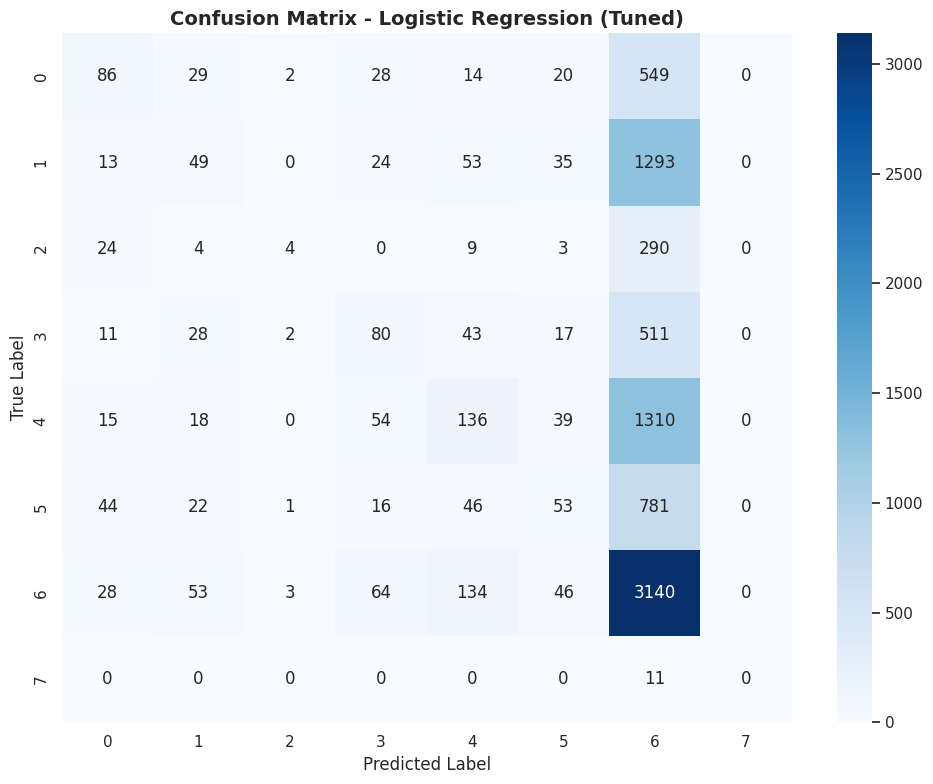

In [ ]:
# -------------------- Cell 8: Confusion Matrix --------------------
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Tuned)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("logistic_regression_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# -------------------- Cell 9: Comparison of Model Varieties --------------------
results = {
    "Model Variety": [
        "Baseline (C=1, no class_weight)",
        "Tuned Best Model"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_baseline), 4),
        round(accuracy_score(y_test, y_pred_best), 4)
    ],
    "F1-Score (Weighted)": [
        round(f1_score(y_test, y_pred_baseline, average='weighted'), 4),
        round(f1_score(y_test, y_pred_best, average='weighted'), 4)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                     Model Variety  Accuracy  F1-Score (Weighted)
0  Baseline (C=1, no class_weight)    0.3835               0.2715
1                 Tuned Best Model    0.3842               0.2772


In [ ]:
# -------------------- Cell 10: Summary for Viva --------------------
print("""
============================================================
LOGISTIC REGRESSION - SUMMARY (IT25102631)
============================================================

1. Model Suitability:
   - Multi-class emotion classification (8 classes)
   - Logistic Regression with multinomial setting is suitable
   - Works well with scaled numerical + binary genre + LSA features

2. Implementation:
   - Library: scikit-learn
   - multi_class='multinomial', solver='lbfgs'/'saga'

3. Hyperparameter Tuning:
   - Method: GridSearchCV + StratifiedKFold (3-fold)
   - Tuned parameters: C, solver, class_weight

4. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted? → Because dataset is imbalanced

5. Validation Method:
   - Stratified Train-Test Split (80/20)
   - Stratified K-Fold inside GridSearchCV

6. Comparison:
   - Baseline vs Tuned model shown above

7. Limitations:
   - Linear decision boundary (may underfit complex patterns)
   - Sensitive to class imbalance (partially handled by class_weight)
   - Does not capture sequential nature of text as well as deep learning

8. Possible Improvements:
   - Try class_weight='balanced' more carefully
   - Add more non-linear models (SVM, Random Forest, MLP)
============================================================
""")


LOGISTIC REGRESSION - SUMMARY (IT25102631)

1. Model Suitability:
   - Multi-class emotion classification (8 classes)
   - Logistic Regression with multinomial setting is suitable
   - Works well with scaled numerical + binary genre + LSA features

2. Implementation:
   - Library: scikit-learn
   - multi_class='multinomial', solver='lbfgs'/'saga'

3. Hyperparameter Tuning:
   - Method: GridSearchCV + StratifiedKFold (3-fold)
   - Tuned parameters: C, solver, class_weight

4. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted? → Because dataset is imbalanced

5. Validation Method:
   - Stratified Train-Test Split (80/20)
   - Stratified K-Fold inside GridSearchCV

6. Comparison:
   - Baseline vs Tuned model shown above

7. Limitations:
   - Linear decision boundary (may underfit complex patterns)
   - Sensitive to class imbalance (partially handled by class_weight)
   - Does not capture sequential nature of text as well as deep learning

8. Poss